# Entraînement et suivi du modèle day-ahead

Nous avançons par comparaison : une baseline métier, un LightGBM simple, puis une version production contrôlée.

Le protocole est fixe : les données anciennes servent à l'entraînement et les trois derniers mois servent uniquement au test final. Pour surveiller l'overfitting pendant l'apprentissage LightGBM, une partie chronologiquement plus récente du train sert de validation.

In [ ]:
import matplotlib.pyplot as plt
import mlflow
import mlflow.lightgbm
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from pathlib import Path

DATA_PATH = Path('../data/eco2mix.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data/eco2mix.csv')
MLFLOW_DB_PATH = Path('../mlflow.db').resolve()
if not MLFLOW_DB_PATH.parent.exists():
    MLFLOW_DB_PATH = Path('mlflow.db').resolve()

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Fichier introuvable : {DATA_PATH.resolve()}')

mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB_PATH.as_posix()}')
mlflow.set_experiment('conso_energie_day_ahead')
print('Fichier utilisé :', DATA_PATH.resolve())

## Préparer les données

On reconstruit les variables à partir de la série propre. Les lags utilisent uniquement des valeurs passées : `lag_48` correspond à 24 heures et `lag_336` à 7 jours. Les variables de production ne sont pas utilisées, car elles pourraient être indisponibles au moment de la prévision.

In [12]:
from pathlib import Path

DATA_PATH = Path('../data/eco2mix.csv')
MLFLOW_DB_PATH = Path('../mlflow.db').resolve()
mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB_PATH.as_posix()}')
mlflow.set_experiment('conso_energie_day_ahead')

data = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
data = data.sort_values('timestamp').drop_duplicates('timestamp')
data = data.set_index('timestamp').asfreq('30min').rename_axis('timestamp').reset_index()

data['hour'] = data['timestamp'].dt.hour
data['minute'] = data['timestamp'].dt.minute
data['dayofweek'] = data['timestamp'].dt.dayofweek
data['month'] = data['timestamp'].dt.month
data['dayofyear'] = data['timestamp'].dt.dayofyear

for lag in [1, 48, 96, 336]:
    data[f'lag_{lag}'] = data['consommation_mw'].shift(lag)

features = ['hour', 'minute', 'dayofweek', 'month', 'dayofyear', 'lag_1', 'lag_48', 'lag_96', 'lag_336']
data = data.dropna(subset=features + ['consommation_mw']).copy()

test_start = data['timestamp'].max() - pd.DateOffset(months=3)
train_data = data[data['timestamp'] < test_start].copy()
test_data = data[data['timestamp'] >= test_start].copy()

validation_start = train_data['timestamp'].max() - pd.DateOffset(months=1)
fit_data = train_data[train_data['timestamp'] < validation_start]
validation_data = train_data[train_data['timestamp'] >= validation_start]

X_fit, y_fit = fit_data[features], fit_data['consommation_mw']
X_validation, y_validation = validation_data[features], validation_data['consommation_mw']
X_train, y_train = train_data[features], train_data['consommation_mw']
X_test, y_test = test_data[features], test_data['consommation_mw']

print(f'Entraînement : {len(train_data):,} lignes')
print(f'Validation  : {len(validation_data):,} lignes')
print(f'Test futur  : {len(test_data):,} lignes')

Entraînement : 231,719 lignes
Validation  : 1,441 lignes
Test futur  : 4,417 lignes


## Fonctions d'évaluation

Cette cellule contient uniquement les métriques communes. Les modèles restent séparés dans leurs propres cellules pour rendre la comparaison lisible.

In [16]:
def calculate_metrics(actual, predicted):
    return {
        'rmse': float(np.sqrt(mean_squared_error(actual, predicted))),
        'mae': float(mean_absolute_error(actual, predicted)),
        'r2': float(r2_score(actual, predicted))
    }

## Run 1 : baseline de persistance à 24 h

Cette baseline est volontairement simple : la consommation prévue est celle observée 48 demi-heures plus tôt. Elle donne le niveau minimal à battre et ne nécessite aucun entraînement.

In [ ]:
baseline_predictions = test_data['lag_48'].to_numpy()
baseline_scores = calculate_metrics(y_test, baseline_predictions)

with mlflow.start_run(run_name='baseline_persistence_24h'):
    mlflow.set_tag('stage', 'baseline')
    mlflow.log_param('method', 'lag_48')
    mlflow.log_metrics(baseline_scores)

print('Résultats baseline :', baseline_scores)

baseline_persistence_24h {'rmse': 3588.834005797456, 'mae': 2406.450758433326, 'r2': 0.6670563035171901}


## Run 2 : LightGBM intermédiaire

On utilise les paramètres par défaut du modèle, avec `random_state=42` pour rendre le résultat reproductible. Le jeu de validation n'est pas le test final : il sert uniquement à observer l'écart train/validation pendant l'apprentissage.

c:\Users\debba\Documents\Adem\conso_energie_prediction\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
2026/09/23 17:14:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


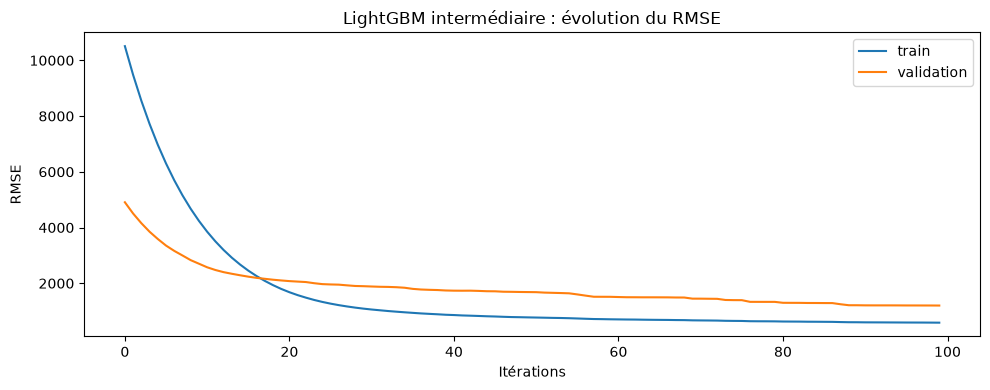

Résultats LightGBM intermédiaire : {'rmse': 464.90231830018394, 'mae': 367.35674252858234, 'r2': 0.9944128867069918}


In [ ]:
intermediate_model = LGBMRegressor(random_state=42, verbosity=-1)
intermediate_model.fit(
    X_fit,
    y_fit,
    eval_set=[(X_fit, y_fit), (X_validation, y_validation)],
    eval_names=['train', 'validation'],
    eval_metric='rmse'
)

intermediate_predictions = intermediate_model.predict(X_test)
intermediate_scores = calculate_metrics(y_test, intermediate_predictions)

learning_curve = intermediate_model.evals_result_
plt.figure(figsize=(10, 4))
plt.plot(learning_curve['train']['rmse'], label='train')
plt.plot(learning_curve['validation']['rmse'], label='validation')
plt.title('LightGBM intermédiaire : évolution du RMSE')
plt.xlabel('Itérations')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.savefig('lightgbm_intermediate_learning_curve.png')
plt.show()

with mlflow.start_run(run_name='lightgbm_default'):
    mlflow.set_tag('stage', 'intermediate')
    mlflow.log_params({'model': 'LightGBM default', 'random_state': 42})
    mlflow.log_metrics(intermediate_scores)
    mlflow.log_artifact('lightgbm_intermediate_learning_curve.png')
    mlflow.lightgbm.log_model(intermediate_model, 'model')

print('Résultats LightGBM intermédiaire :', intermediate_scores)

## Run 3 : LightGBM production avec contrôle de l'overfitting

Les paramètres sont choisis pour obtenir un modèle plus stable : un learning rate modéré, davantage d'arbres et un nombre de feuilles limité. L'early stopping arrête l'apprentissage si le RMSE de validation ne s'améliore plus pendant 50 itérations.

c:\Users\debba\Documents\Adem\conso_energie_prediction\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


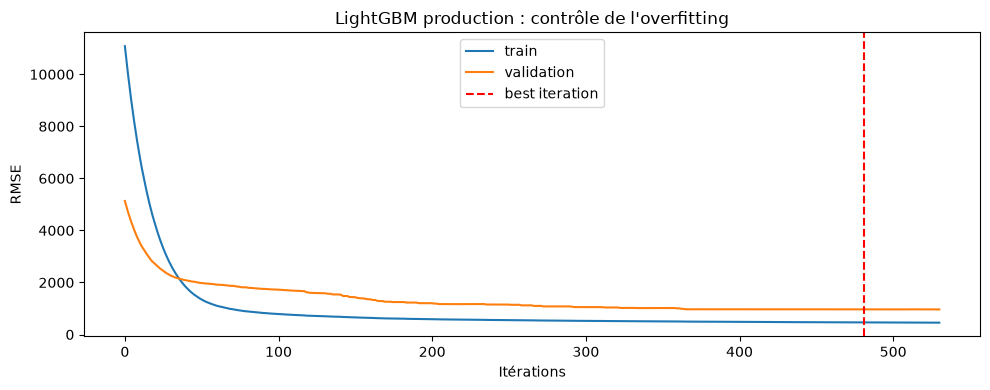

2026/09/23 17:15:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Meilleure itération : 481
Résultats LightGBM production : {'rmse': 411.3448550934005, 'mae': 318.836449169324, 'r2': 0.9956260260356234}


In [18]:
from lightgbm import early_stopping

production_parameters = {
    'learning_rate': 0.05,
    'n_estimators': 1000,
    'num_leaves': 31,
    'max_depth': -1,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'random_state': 42,
    'verbosity': -1
}

production_model = LGBMRegressor(**production_parameters)
production_model.fit(
    X_fit,
    y_fit,
    eval_set=[(X_fit, y_fit), (X_validation, y_validation)],
    eval_names=['train', 'validation'],
    eval_metric='rmse',
    callbacks=[early_stopping(50, verbose=False)]
)

production_predictions = production_model.predict(X_test)
production_scores = calculate_metrics(y_test, production_predictions)

learning_curve = production_model.evals_result_
plt.figure(figsize=(10, 4))
plt.plot(learning_curve['train']['rmse'], label='train')
plt.plot(learning_curve['validation']['rmse'], label='validation')
plt.axvline(production_model.best_iteration_, color='red', linestyle='--', label='best iteration')
plt.title("LightGBM production : contrôle de l'overfitting")
plt.xlabel('Itérations')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.savefig('lightgbm_production_learning_curve.png')
plt.show()

with mlflow.start_run(run_name='lightgbm_production'):
    mlflow.set_tag('stage', 'production')
    mlflow.log_params(production_parameters)
    mlflow.log_param('best_iteration', production_model.best_iteration_)
    mlflow.log_metrics(production_scores)
    mlflow.log_artifact('lightgbm_production_learning_curve.png')
    mlflow.lightgbm.log_model(production_model, 'model')

print('Meilleure itération :', production_model.best_iteration_)
print('Résultats LightGBM production :', production_scores)

,model,rmse,mae,r2
2,lightgbm_production,411.344855,318.836449,0.995626
1,lightgbm_intermediate,464.902318,367.356743,0.994413
0,baseline,3588.834006,2406.450758,0.667056


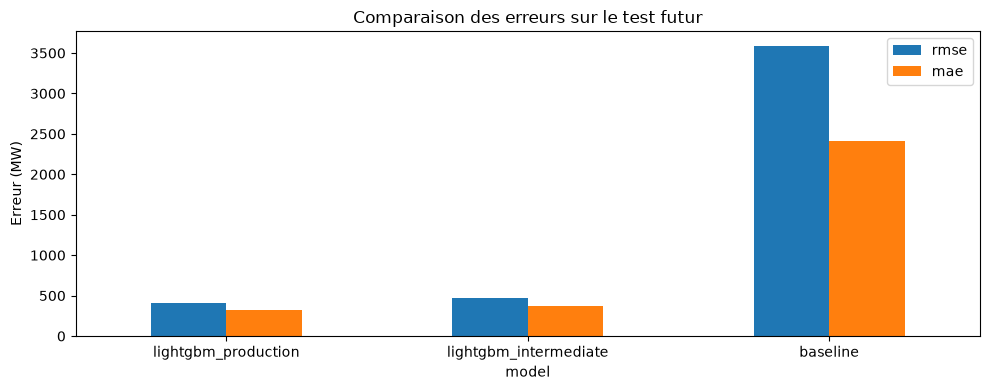

,timestamp,consommation_mw,baseline,lightgbm_intermediate,lightgbm_production
232172,2026-03-30 21:30:00+00:00,56766.0,55843.0,57139.553520,57293.689080
232173,2026-03-30 22:00:00+00:00,56547.0,55407.0,57472.859588,57241.649479
232174,2026-03-30 22:30:00+00:00,55630.0,54792.0,55816.752415,55574.766635
232175,2026-03-30 23:00:00+00:00,53692.0,53066.0,54230.275931,54032.745255
232176,2026-03-30 23:30:00+00:00,53236.0,52920.0,52786.948919,52740.347311


In [19]:
results = pd.DataFrame([
    {'model': 'baseline', **baseline_scores},
    {'model': 'lightgbm_intermediate', **intermediate_scores},
    {'model': 'lightgbm_production', **production_scores}
]).sort_values('rmse')

display(results)

results.set_index('model')[['rmse', 'mae']].plot(kind='bar', figsize=(10, 4))
plt.title('Comparaison des erreurs sur le test futur')
plt.ylabel('Erreur (MW)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

comparison = test_data[['timestamp', 'consommation_mw']].copy()
comparison['baseline'] = baseline_predictions
comparison['lightgbm_intermediate'] = intermediate_predictions
comparison['lightgbm_production'] = production_predictions
display(comparison.head())

## Lecture des résultats et règles de décision

- Le modèle production doit battre la baseline sur le RMSE et la MAE du test futur.
- Une courbe train qui baisse alors que validation remonte signale de l'overfitting : on conserve l'early stopping, on réduit `num_leaves` ou on augmente la régularisation.
- Une courbe train et validation trop proches mais avec de fortes erreurs signale du sous-apprentissage : on peut enrichir les features ou augmenter modérément la complexité.
- Les courbes et les métriques doivent être enregistrées comme artefacts MLflow dans une prochaine itération ; les métriques principales sont déjà loggées dans `mlflow.db`.

Le serveur MLflow recommandé pour consulter les résultats est :

```powershell
mlflow server --backend-store-uri sqlite:///mlflow.db --host 127.0.0.1 --port 5000
```

Puis ouvrir `http://127.0.0.1:5000`.